In [1]:
import torch.optim as optim
import matplotlib.pyplot as plt

from src.load_and_save import save_model
from src.model import SimpleNN
from src.pruning import get_intermediate_outputs_as_numpy
from src.training import get_accuracy
from src.utils import device
from settings import settings
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn as nn
import torch

from src.pruning import is_all_layers_separated
import numpy as np



In [2]:
# Define the number of classes in MNIST (digits 0-9)
num_classes = 10

# Define the transformation to apply to the images
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Lambda(lambda x: x.view(-1))  # Flatten the images to a single dimension
])

# Custom transform to one-hot encode the labels
class OneHotEncode:
    def __init__(self, num_classes):
        self.num_classes = num_classes

    def __call__(self, label):
        return torch.eye(self.num_classes)[label]

# Load the full training dataset
full_train_dataset = datasets.MNIST(
    root=settings.data_path,
    train=True,
    download=True,
    transform=transform,
    target_transform=OneHotEncode(num_classes)
)

# Split the full training dataset into training and validation datasets
train_size = int(0.8 * len(full_train_dataset))  # 80% for training
val_size = len(full_train_dataset) - train_size  # 20% for validation
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Load the test dataset
test_dataset = datasets.MNIST(
    root=settings.data_path,
    train=False,
    download=True,
    transform=transform,
    target_transform=OneHotEncode(num_classes)
)

# Create DataLoaders for training, validation, and test sets
train_dataloader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=512, shuffle=False)

In [3]:
# Instantiate the model
model = SimpleNN(784, 10, 2.0).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=float(1e-2))

In [4]:

# Training loop
num_epochs: int = 25
for epoch in range(num_epochs):
    for inputs, labels in train_dataloader:
        if epoch == 0:
            break
        # Forward pass
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Assess progress:
    data: np.ndarray = get_intermediate_outputs_as_numpy(model, train_dataloader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Accuracy: {get_accuracy(model, val_dataloader):.4f}, Is layer separated: {is_all_layers_separated(data)}')


Epoch [1/25], Accuracy: 0.0628, Is layer separated: False
Epoch [2/25], Accuracy: 0.8634, Is layer separated: False
Epoch [3/25], Accuracy: 0.8996, Is layer separated: False
Epoch [4/25], Accuracy: 0.9134, Is layer separated: False
Epoch [5/25], Accuracy: 0.9188, Is layer separated: False
Epoch [6/25], Accuracy: 0.9262, Is layer separated: False
Epoch [7/25], Accuracy: 0.9287, Is layer separated: False
Epoch [8/25], Accuracy: 0.9317, Is layer separated: False
Epoch [9/25], Accuracy: 0.9342, Is layer separated: False
Epoch [10/25], Accuracy: 0.9349, Is layer separated: False
Epoch [11/25], Accuracy: 0.9367, Is layer separated: False
Epoch [12/25], Accuracy: 0.9387, Is layer separated: False
Epoch [13/25], Accuracy: 0.9354, Is layer separated: False
Epoch [14/25], Accuracy: 0.9392, Is layer separated: False
Epoch [15/25], Accuracy: 0.9418, Is layer separated: False
Epoch [16/25], Accuracy: 0.9428, Is layer separated: False
Epoch [17/25], Accuracy: 0.9443, Is layer separated: False
Epoch 

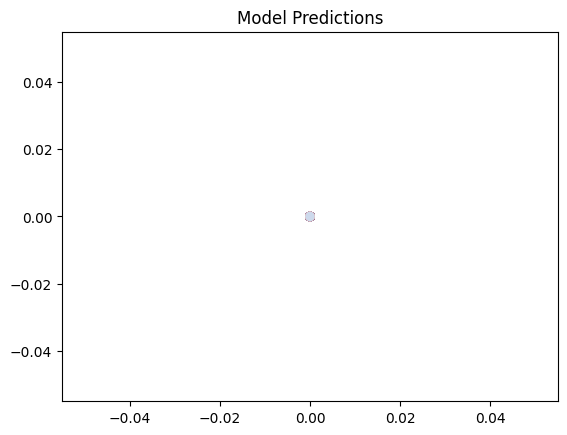

In [5]:
# Generate test data
model.eval_mode()

test_data, test_labels = next(iter(test_dataloader))
test_data, test_labels = test_data.to(device), test_labels.to(device)

# Get model predictions
with torch.no_grad():
    predictions = model(test_data)
    predicted_labels = torch.argmax(predictions, axis=1)

# Convert tensors to lists for plotting
x_coords = test_data[:, 0].tolist()
y_coords = test_data[:, 1].tolist()
predicted_labels = predicted_labels.tolist()

# Plot the results using lists
plt.scatter(x_coords, y_coords, c=predicted_labels, cmap='coolwarm', marker='o')
plt.title('Model Predictions')
plt.show()
index = 0

In [9]:
intermediate_layer = model.layer1(test_data)

index = (index + 1) % intermediate_layer.size()[1]

first_node = intermediate_layer[:,index].tolist()

first_node_np = np.array(first_node)

def get_quantile_of_separation(intermediate_output: list[float], quantile: float) -> float:
    return np.quantile(abs(np.array(intermediate_output)), quantile)


all_quantiles = []
for i in range(intermediate_layer.shape[1]):
    intermediate_output = intermediate_layer[:,i].tolist()
    all_quantiles.append(get_quantile_of_separation(intermediate_output, 0.05))

print(np.mean(all_quantiles))


#model.layer1.bias
# plt.hist(first_node)
# print(get_quantile_of_separation(first_node, 0.05))

0.6213147725164891


In [7]:
0.6104

0.6104

In [8]:
np.quantile(abs(first_node_np), 0.01)


0.08602380633354187